# Chapter 2 Federated Analysis

##  Dirichlet Partitioning: How Heterogeneity Distorts Client Distributions

This is the core of the experimental design. For each α value we generate one
partitioning of patients into 5 clients and visualize:
- The positive rate per client (how skewed the label distributions are).
- The Wasserstein distance of each client's key feature distributions from the global.

The Wasserstein distance $W_1$ is the natural measure of distribution divergence here
because it corresponds directly to the $d_{\mathcal{H}\Delta\mathcal{H}}$ term in
Theorem 1 of the FedGen paper — larger $W_1$ predicts worse global model performance.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, entropy, ks_2samp
import warnings
import sys
import os
import json

warnings.filterwarnings('ignore')
sys.path.append('..')

from UC1Utils import (
    load_data, drop_columns, remove_deceased, create_target,
    encode_features, _impute_and_group_specialty,
    prepare_data, ensure_data, CSV_MAIN, derive_global_columns, prepare_data_preohe
)
from UC1FLUtils import dirichlet_partition, find_feasible_params, preprocess_clients, verify_leakage, load_clients, create_clients_raw_csv, load_partitions_from_disk

from UC1PrintingUtils import (
    compute_wasserstein_df,
    compute_js_df,
    compute_eff_df,
    compute_heterogeneity_metrics,
    plot_wasserstein_bars,
    plot_mean_w1_line,
    plot_js_covariate_shift,
    plot_n_pos_per_client,
    print_client_summary,
    plot_client_distribution,
    plot_label_prior,
    plot_heterogeneity_summary,
    compute_gini_df,
    plot_gini_per_client_bars,
    plot_gini_lines,
)

plt.rcParams.update({
    'figure.dpi':       130,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})
PALETTE = {'Not readmitted (0)': '#4878CF', 'Readmitted <30d (1)': '#E24A33'}
ALPHA_SWEEP = [0.1, 0.5, 1.0, 5.0,10.0]
N_CLIENTS   = 5
SEED        = 42
FEDERATED_DIR  = '../federated_data'
FILTERED_DIR   = os.path.join(FEDERATED_DIR, 'filtered')
UNFILTERED_DIR = os.path.join(FEDERATED_DIR, 'unfiltered')

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
ensure_data()
df  = prepare_data_preohe(CSV_MAIN)          
X, y, groups, feature_names = prepare_data(CSV_MAIN, verbose=True)

✓ CSV files already present, skipping extraction.
dropna removed 1518 rows (1.53%) — likely from unmapped admission_type/source IDs
Dataset shape after cleaning: (97825, 101)
Class distribution:
readmitted_binary
0    86618
1    11207
Name: count, dtype: int64
Imbalance ratio: 7.73:1  (positive rate: 11.46%)


In [3]:
# Build patient → label map from the full dataset
df_full_raw = pd.read_csv(CSV_MAIN)
patient_labels_map = (
    df_full_raw.groupby('patient_nbr')['readmitted']
    .apply(lambda x: 1 if (x == '<30').any() else 0)
    .to_dict()
)
unique_patients = np.array(list(patient_labels_map.keys()))

print(f'Unique patients: {len(unique_patients):,}')
print(f'Positive patients (ever readmitted <30d): {sum(patient_labels_map.values()):,}')

Unique patients: 71,518
Positive patients (ever readmitted <30d): 8,834


In [4]:
# ── Federation Setup: paths and global feature schema ─────────────────────────
# Schema is derived once from the full dataset and saved to disk.
# All client preprocessing aligns to this schema so every client produces
# identical feature dimensions regardless of which rare categories appear locally.

os.makedirs(FEDERATED_DIR, exist_ok=True)

global_columns = derive_global_columns(CSV_MAIN)

schema_path = os.path.join(FEDERATED_DIR, 'feature_schema.json')
with open(schema_path, 'w') as f:
    json.dump(global_columns, f, indent=2)

print(f'Global schema: {len(global_columns)} columns saved → {schema_path}')

Deriving global feature schema from full dataset...
  99 feature columns
Global schema: 99 columns saved → ../federated_data/feature_schema.json


In [5]:
find_feasible_params(df_full_raw, n_clients_list=[5], alpha_list=[0.5, 1.0, 5.0, 10.0])

Total patients: 71,518 | Positive: 8,834 (12.4%)

 N_clients |    Alpha |  Feasible trials |   Mean min pos_abs |  p5 min pos_abs
---------------------------------------------------------------------------
         5 |    0.500 |              24% |              435.6 |           212.9
         5 |    1.000 |              62% |              533.8 |           223.4
         5 |    5.000 |             100% |              955.0 |           508.6
         5 |   10.000 |             100% |             1162.4 |           758.6


In [6]:
new_data = False
PARTITION_SEED = 42

# ── Filtered ──────────────────────────────────────────────────────────────────
if new_data:
    filtered_partitions = create_clients_raw_csv(
        df_full_raw, FILTERED_DIR, ALPHA_SWEEP,
        filtered=True, seed=PARTITION_SEED
    )
    preprocess_clients(
        FILTERED_DIR, ALPHA_SWEEP, global_columns,
        seed=PARTITION_SEED, regenerate=True
    )
else:
    filtered_partitions = load_partitions_from_disk(
        FILTERED_DIR, ALPHA_SWEEP, patient_labels_map
    )
verify_leakage(ALPHA_SWEEP, output_dir=FILTERED_DIR)

# ── Unfiltered ────────────────────────────────────────────────────────────────
if new_data:
    unfiltered_partitions = create_clients_raw_csv(
        df_full_raw, UNFILTERED_DIR, ALPHA_SWEEP,
        filtered=False, seed=PARTITION_SEED
    )
    preprocess_clients(
        UNFILTERED_DIR, ALPHA_SWEEP, global_columns,
        seed=PARTITION_SEED, regenerate=True
    )
else:
    unfiltered_partitions = load_partitions_from_disk(
        UNFILTERED_DIR, ALPHA_SWEEP, patient_labels_map
    )
verify_leakage(ALPHA_SWEEP, output_dir=UNFILTERED_DIR)

  α=0.1 → 5 clients | sizes: ['33,383', '1,429', '26,817', '3,914', '5,975'] | pos rates: ['0.067', '0.903', '0.049', '0.883', '0.087']
  α=0.5 → 5 clients | sizes: ['3,675', '24,488', '21,343', '2,151', '19,861'] | pos rates: ['0.235', '0.073', '0.227', '0.105', '0.056']
  α=1.0 → 5 clients | sizes: ['22,334', '33,325', '3,889', '5,001', '6,969'] | pos rates: ['0.135', '0.034', '0.200', '0.293', '0.349']
  α=5.0 → 5 clients | sizes: ['21,833', '13,524', '6,993', '13,316', '15,852'] | pos rates: ['0.076', '0.140', '0.070', '0.306', '0.045']
  α=10.0 → 5 clients | sizes: ['19,544', '13,943', '8,922', '13,646', '15,463'] | pos rates: ['0.090', '0.138', '0.088', '0.247', '0.065']

Loaded partitions for α ∈ [0.1, 0.5, 1.0, 5.0, 10.0]
  α=0.1: ✓ zero leakage confirmed
  α=0.5: ✓ zero leakage confirmed
  α=1.0: ✓ zero leakage confirmed
  α=5.0: ✓ zero leakage confirmed
  α=10.0: ✓ zero leakage confirmed
  α=0.1 → 5 clients | sizes: ['3', '20', '62,657', '8,146', '692'] | pos rates: ['0.000',

## Wasserstein Distance: Client vs. Global Distribution

For each (α, client, feature) triplet, we compute the 1-Wasserstein distance between
the client's feature distribution and the global distribution. This quantifies how
much the Dirichlet split distorts each feature's distribution, and for which features
the distortion is strongest.

This directly operationalizes the $d_{\mathcal{H}\Delta\mathcal{H}}$ term from
FedGen's Theorem 1: clients with high Wasserstein distances on discriminative features
are the ones that will benefit most from the generator's inductive bias.

## Filtered


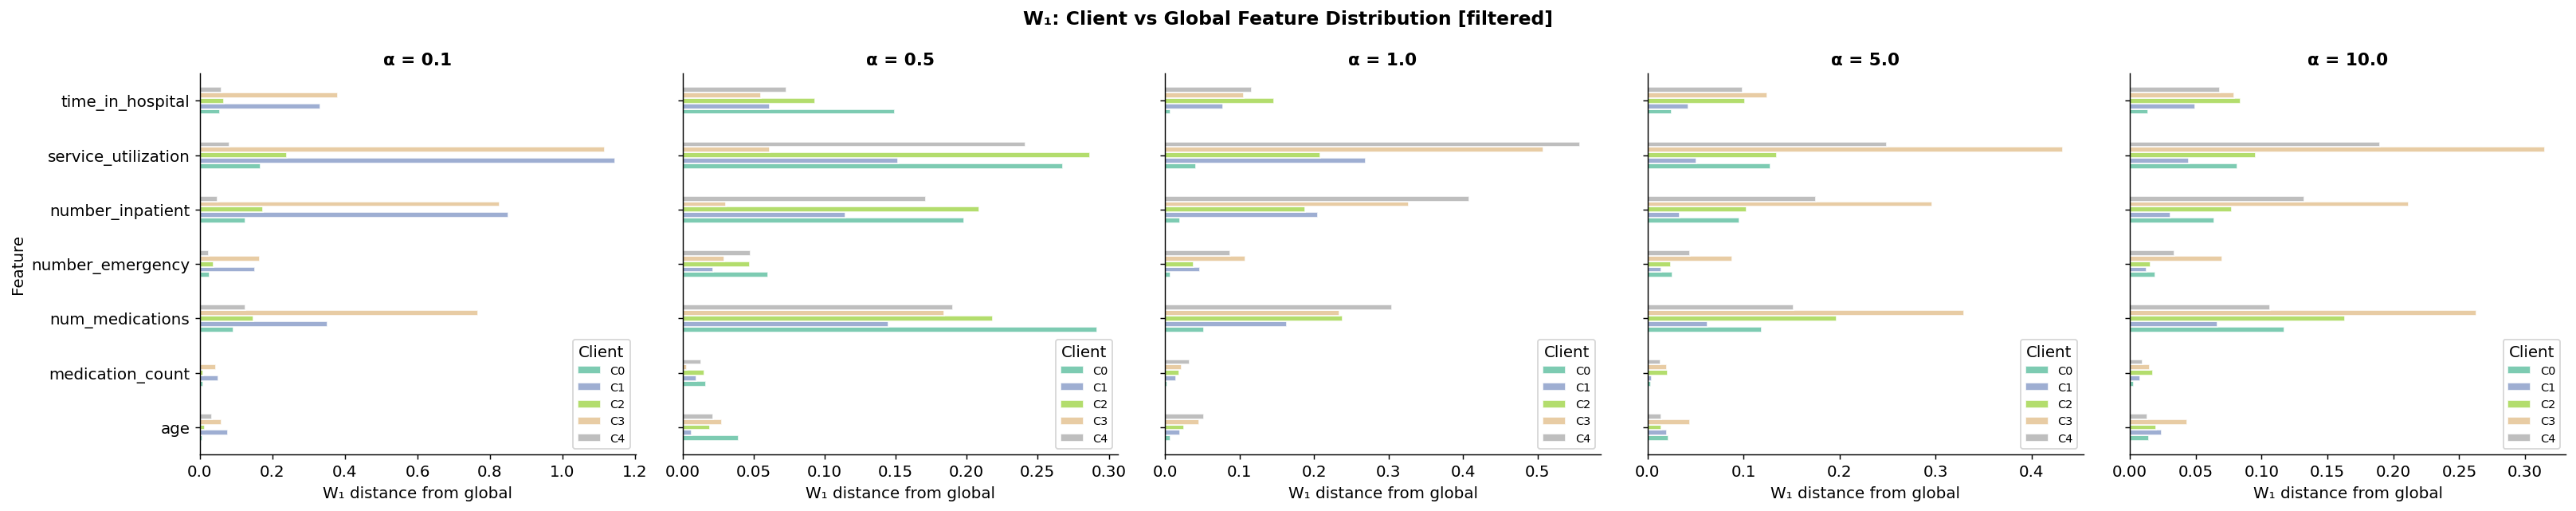

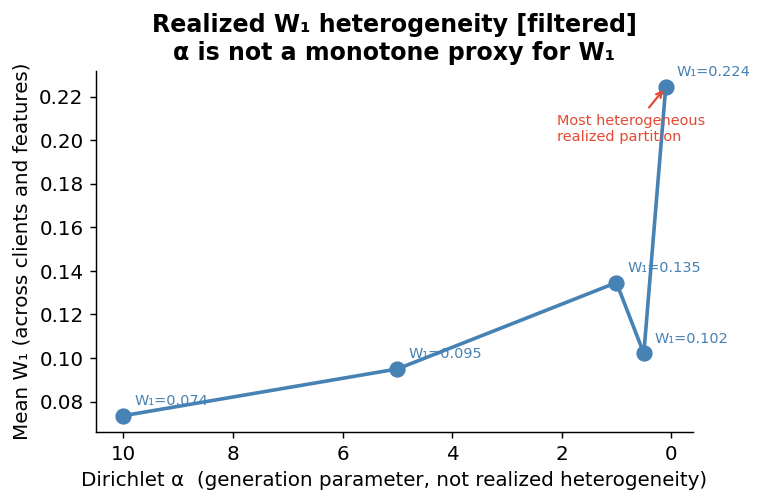

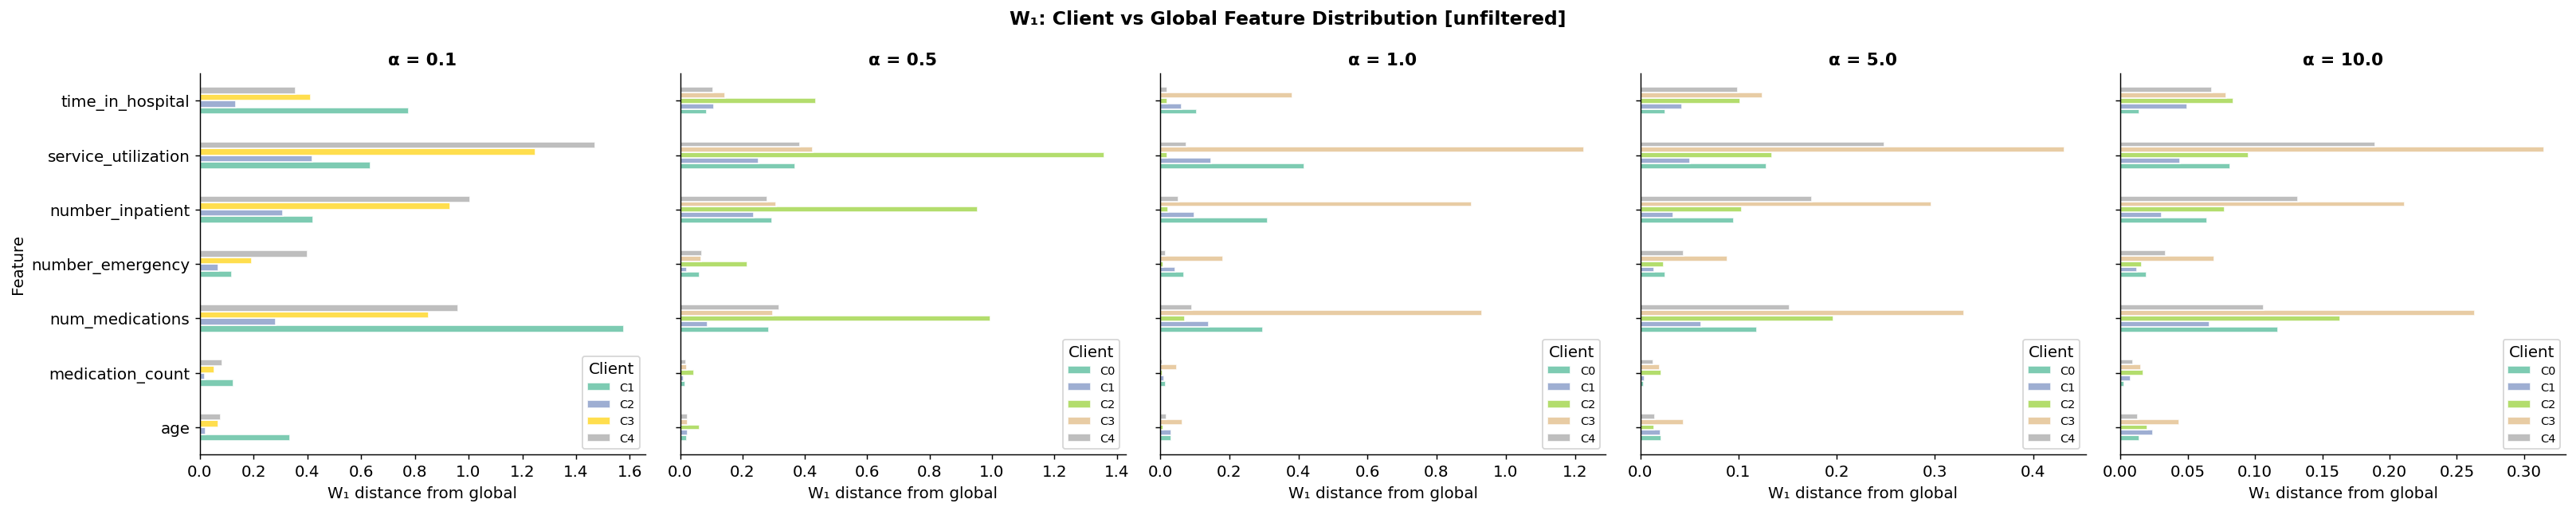

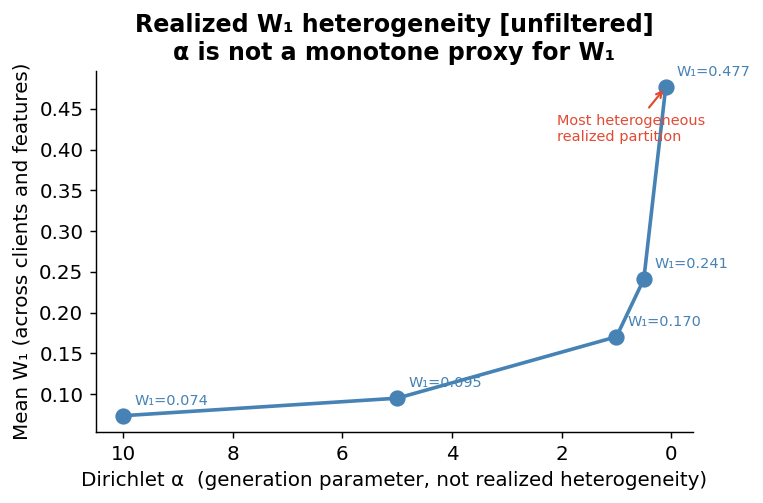

In [7]:
wass_df_filtered   = compute_wasserstein_df(filtered_partitions,   df)
wass_df_unfiltered = compute_wasserstein_df(unfiltered_partitions, df)

for wass_df, label in [(wass_df_filtered, 'filtered'),
                        (wass_df_unfiltered, 'unfiltered')]:
    plot_wasserstein_bars(wass_df, ALPHA_SWEEP, label)
    plot_mean_w1_line(wass_df, label)

## Label Shift vs Covariate Shift

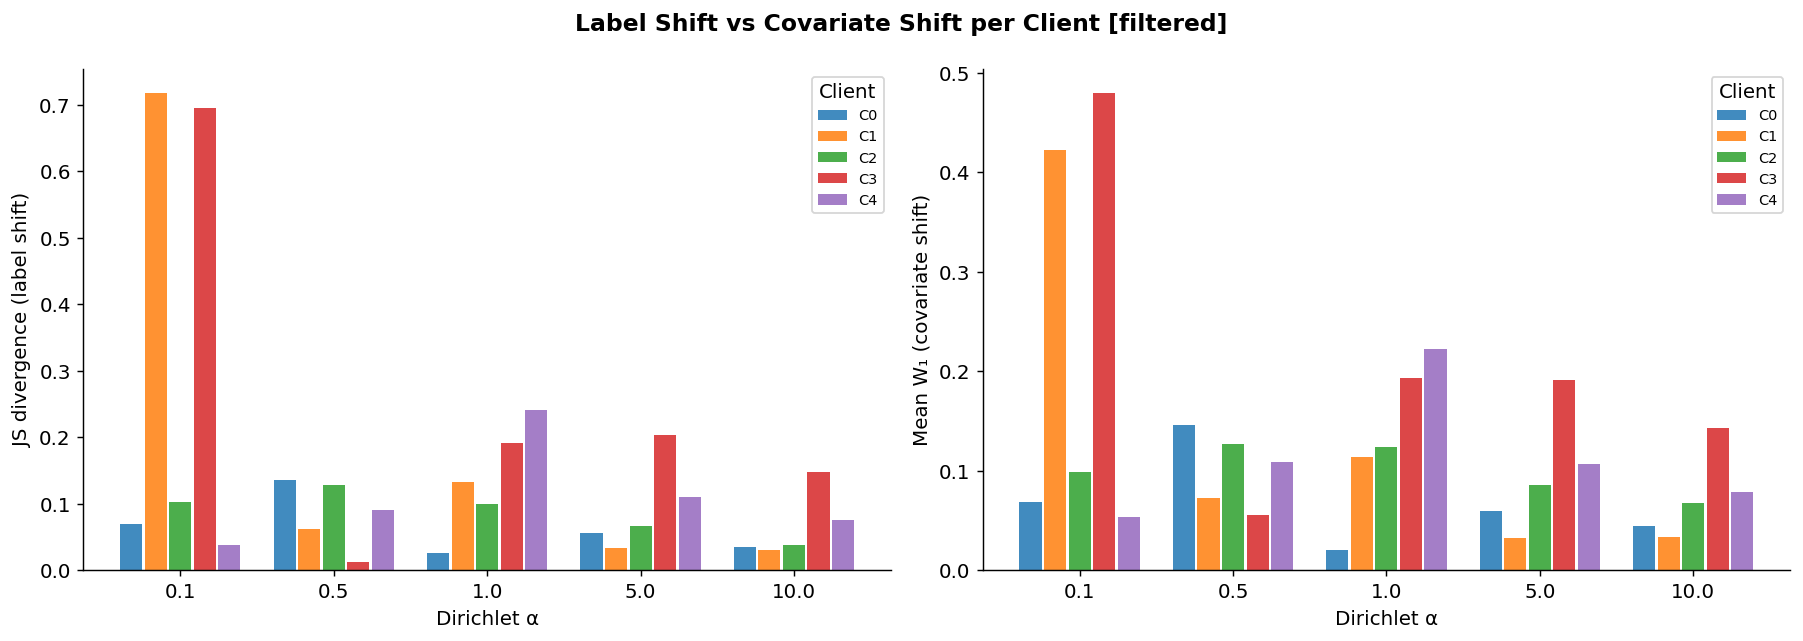

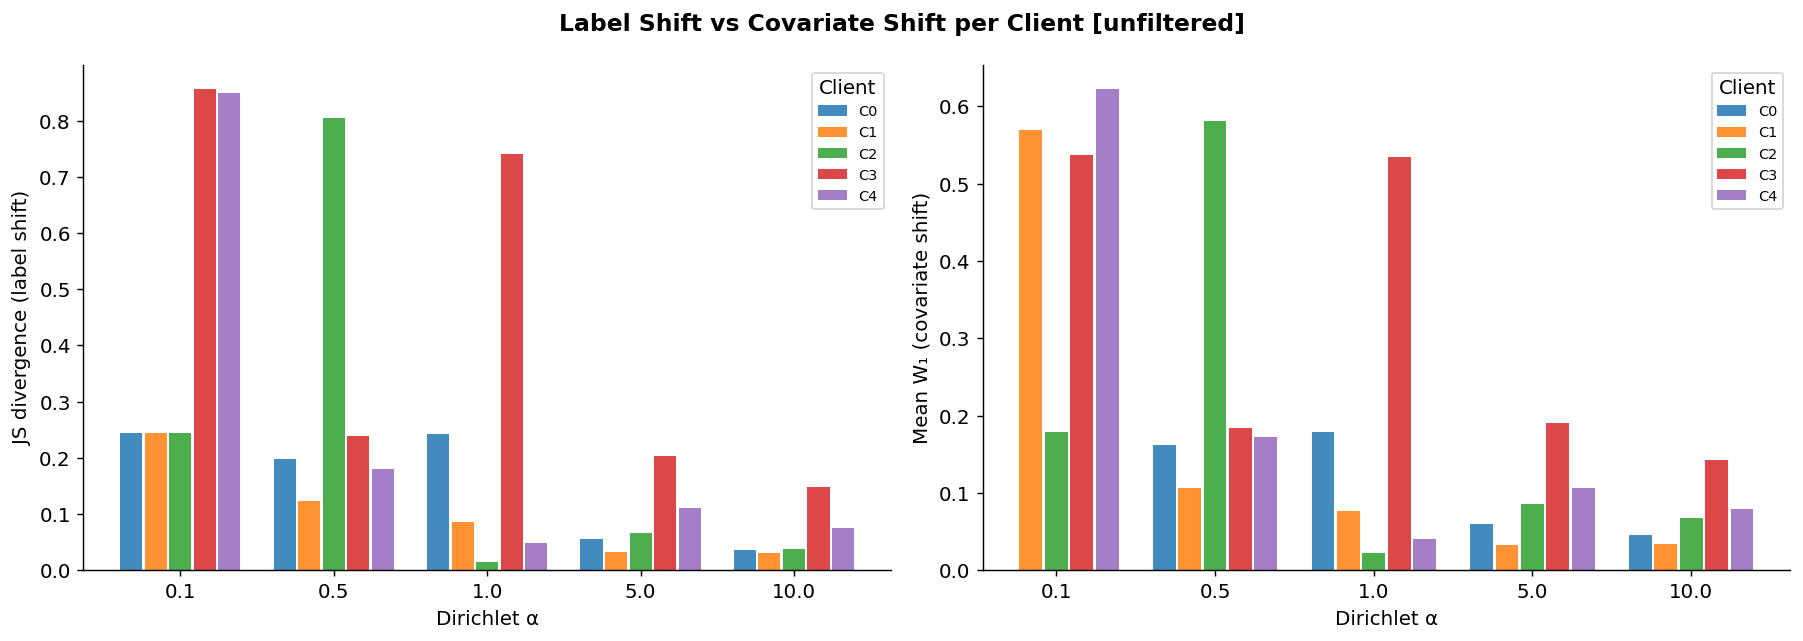

In [8]:
js_df_filtered   = compute_js_df(filtered_partitions,   patient_labels_map, y, wass_df_filtered)
js_df_unfiltered = compute_js_df(unfiltered_partitions, patient_labels_map, y, wass_df_unfiltered)

for js_df, label in [(js_df_filtered, 'filtered'), (js_df_unfiltered, 'unfiltered')]:
    plot_js_covariate_shift(js_df, label)

## 10. Distribution of W1 Across Clients

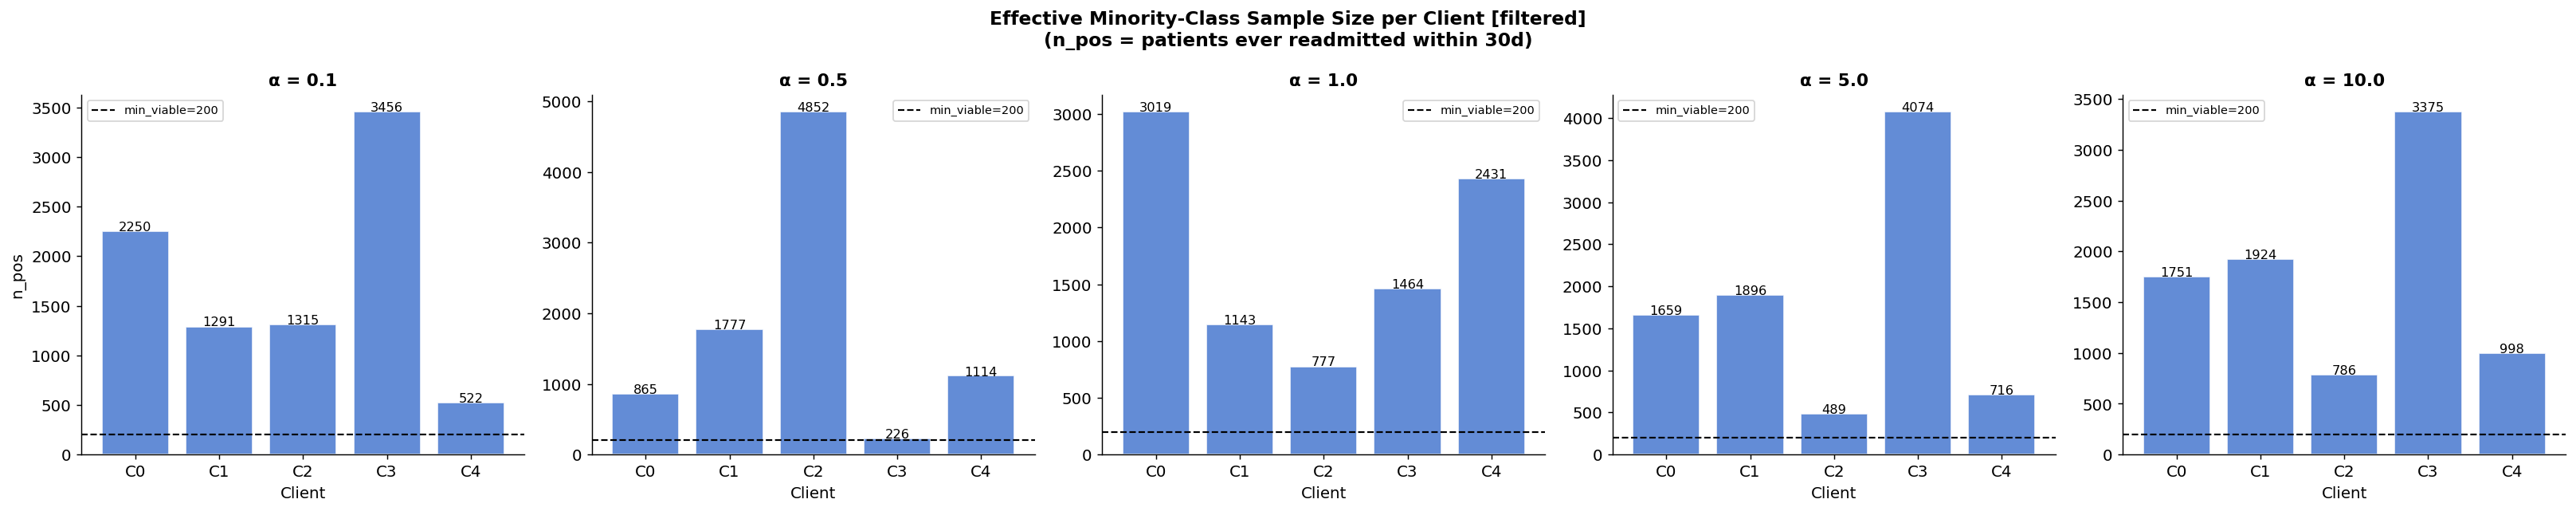


─────────────────────────────────────────────────────────────────
  [filtered] α=0.1 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     28,959    5,040    8,482         99      0.068
  client_1      2,472      470      754         99      0.437
  client_2     22,830    4,088    6,748         99      0.050
  client_3      6,799    1,212    2,059         99      0.432
  client_4      5,401      930    1,581         99      0.090

─────────────────────────────────────────────────────────────────
  [filtered] α=0.5 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0      3,802      687    1,169         99      0.184
  client_1     21,345    3,688    6,378         99      0.073
  client_2     22,298    3,938    6,548         99      0.188
  client_3      2,004      356      566   

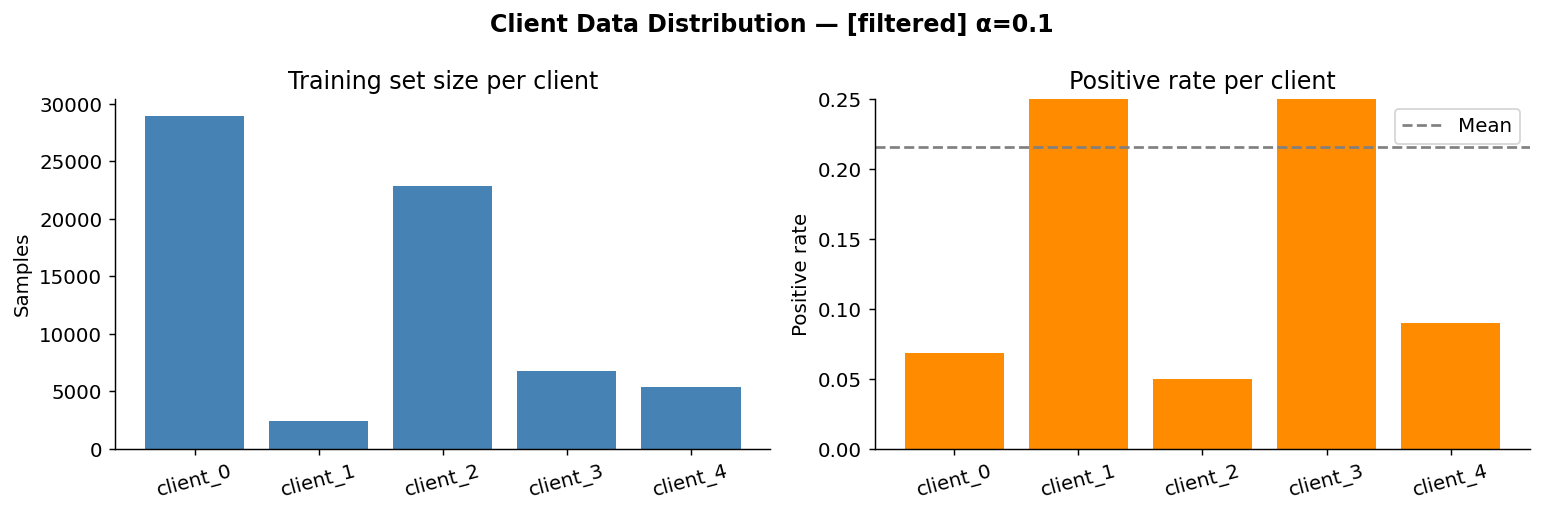

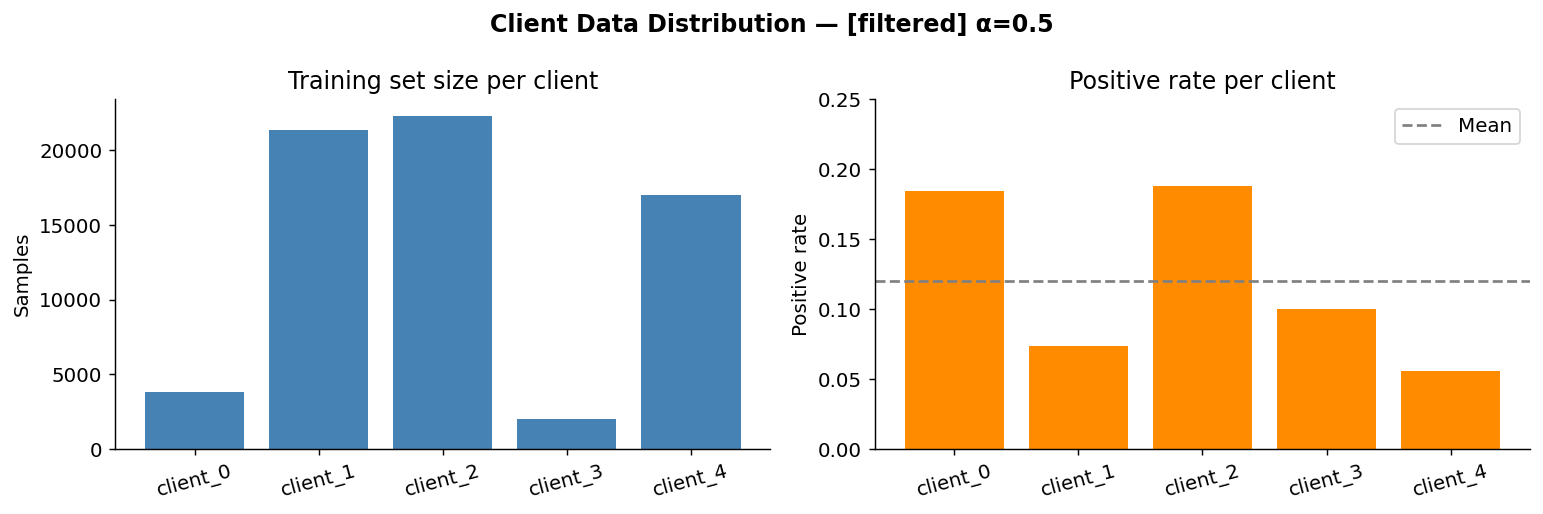

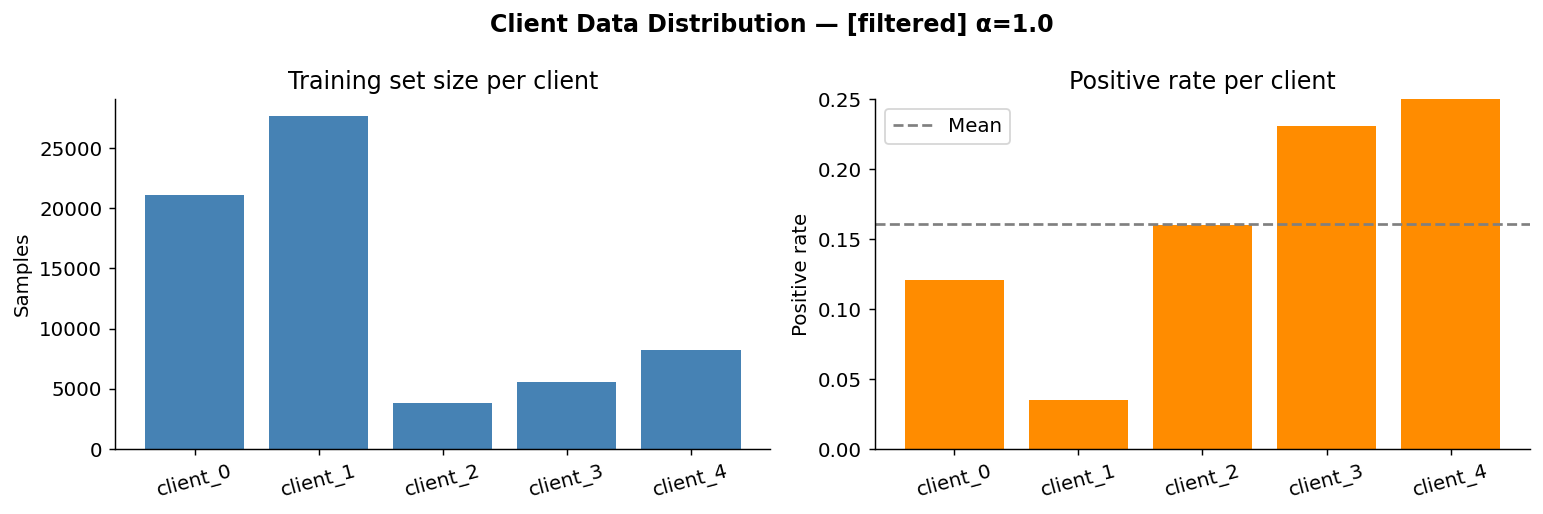

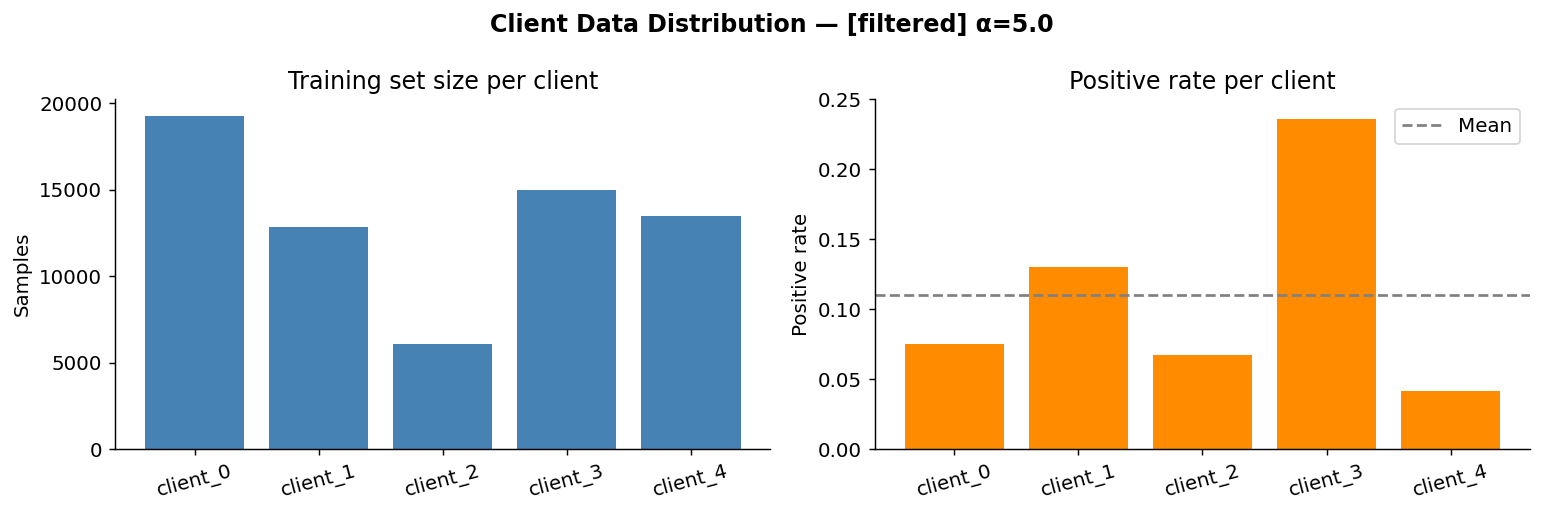

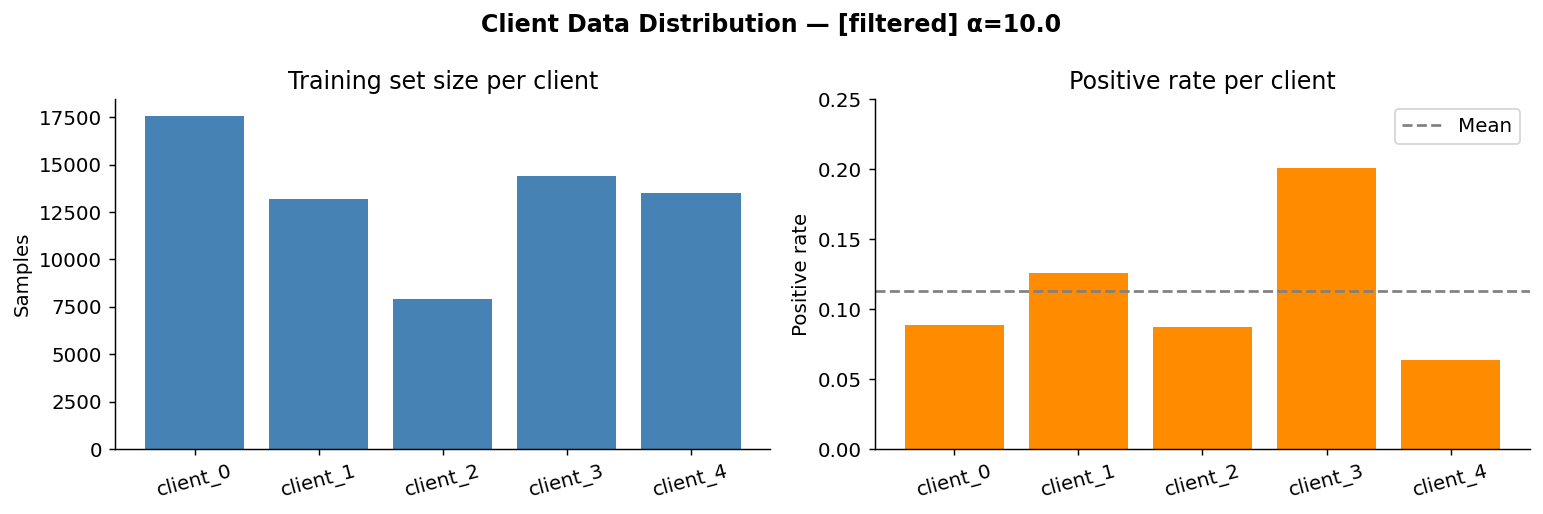

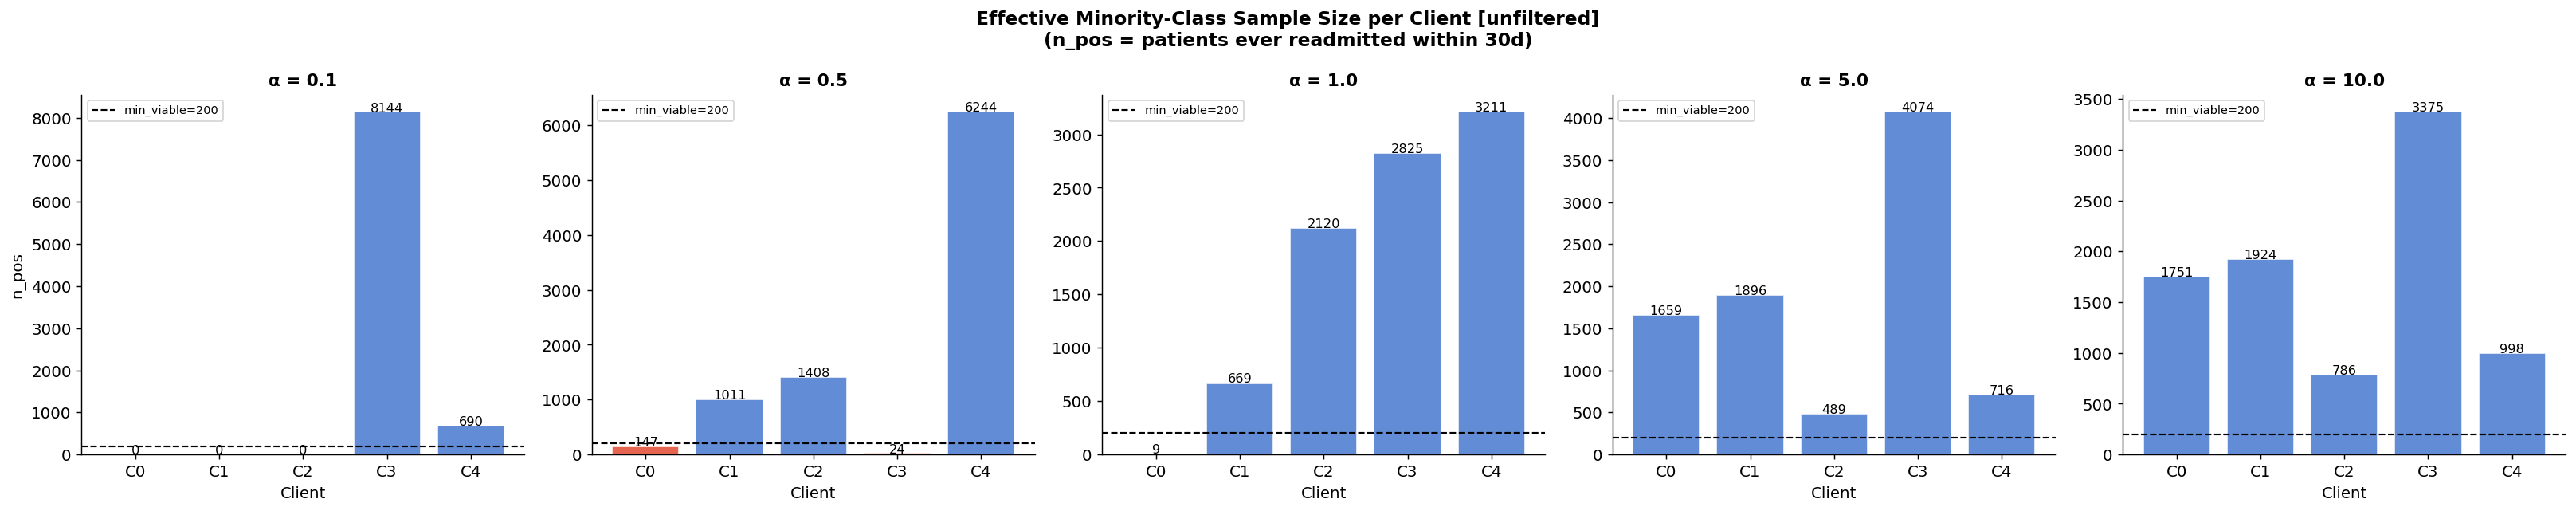


─────────────────────────────────────────────────────────────────
  [unfiltered] α=0.1 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0          2        1        1         99      0.000
  client_1         14        3        4         99      0.000
  client_2     50,082    8,864   14,544         99      0.000
  client_3     15,085    2,693    4,536         99      0.465
  client_4      1,370      230      396         99      0.437

─────────────────────────────────────────────────────────────────
  [unfiltered] α=0.5 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     11,874    2,088    3,614         99      0.011
  client_1      4,709      869    1,377         99      0.184
  client_2      2,652      459      767         99      0.454
  client_3     22,704    3,981    6,66

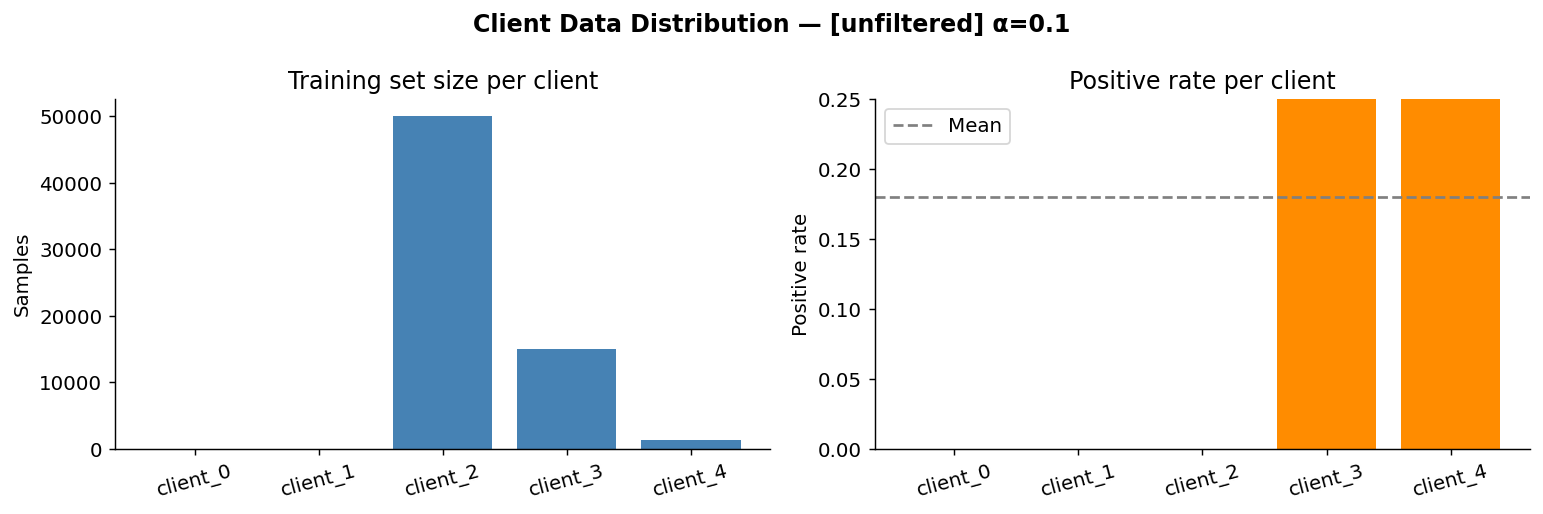

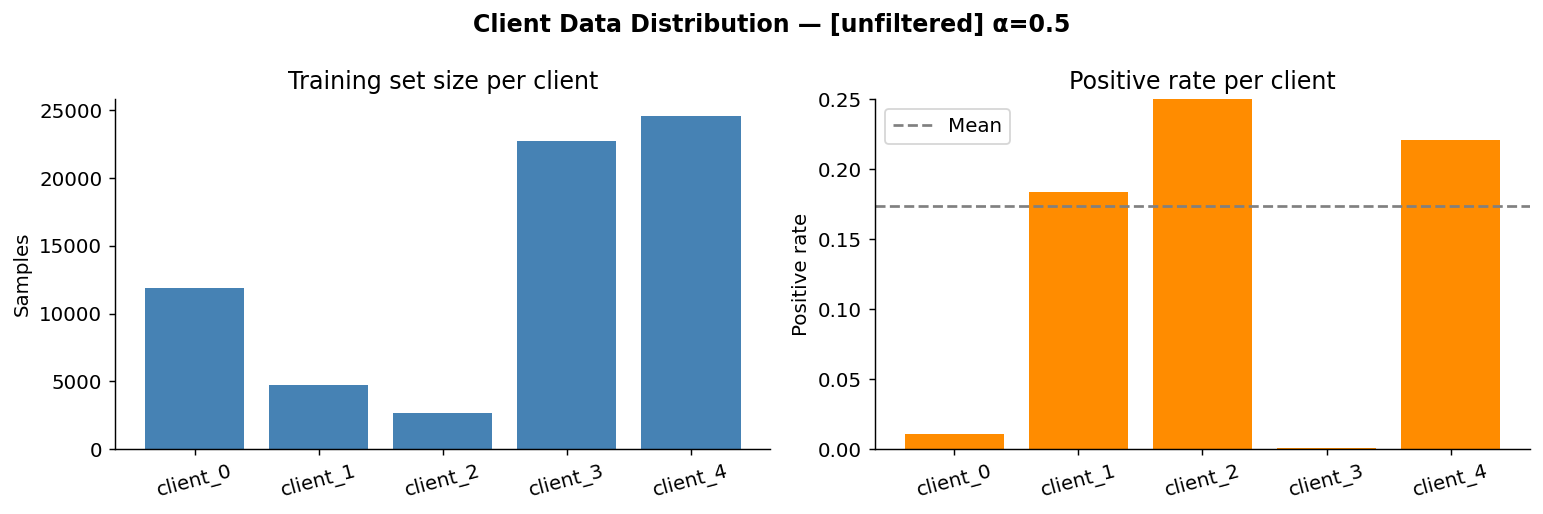

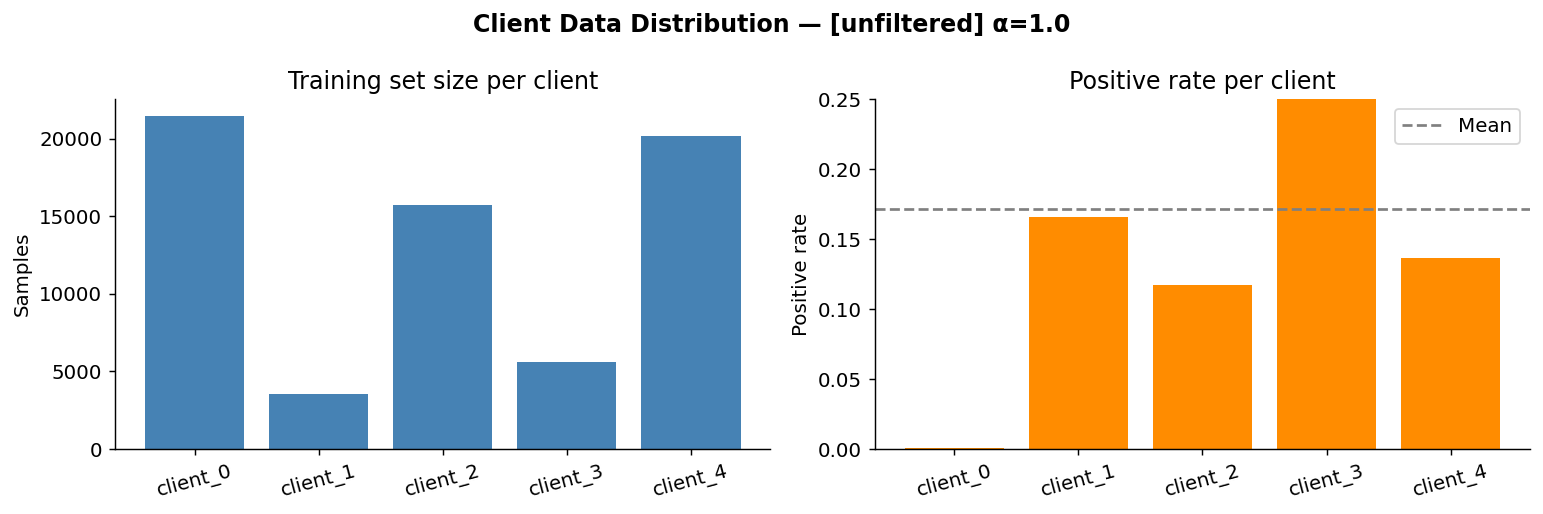

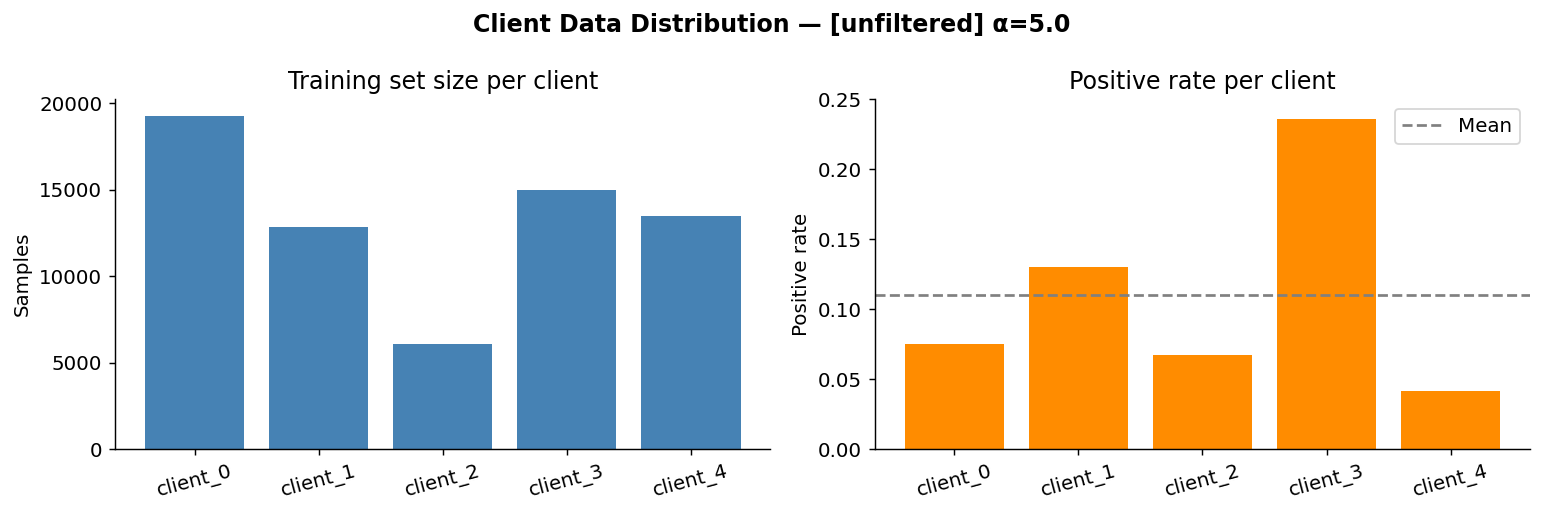

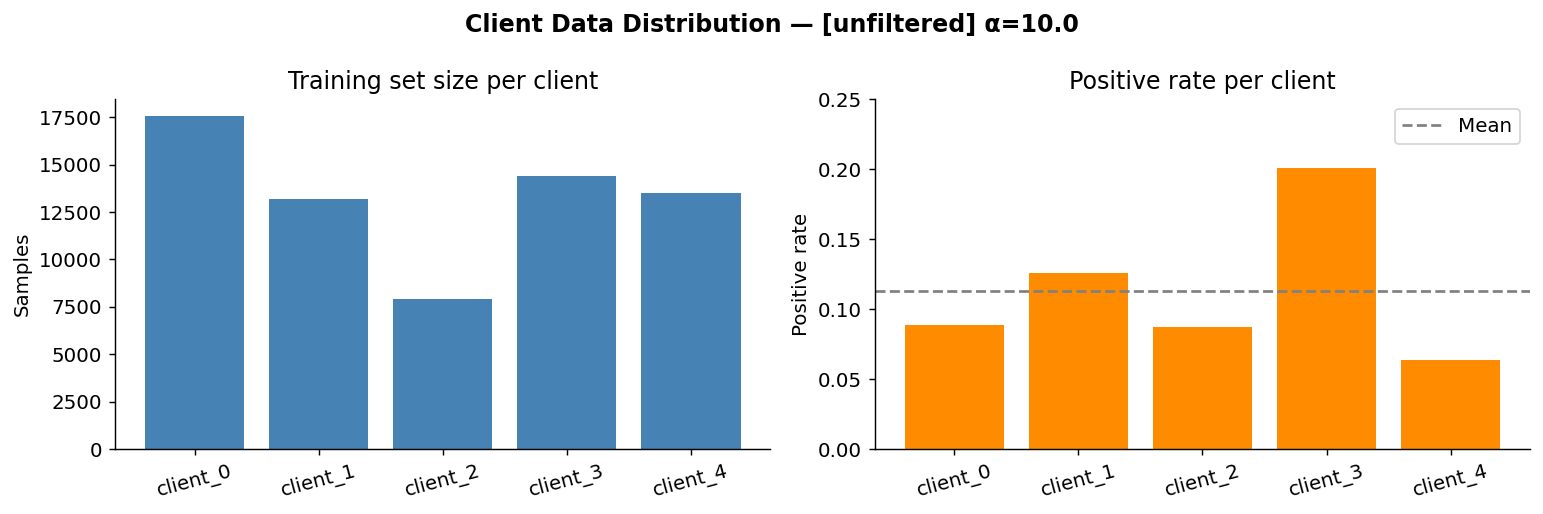

In [9]:
eff_df_filtered   = compute_eff_df(filtered_partitions,   patient_labels_map)
eff_df_unfiltered = compute_eff_df(unfiltered_partitions, patient_labels_map)

for eff_df, label, base_dir in [
    (eff_df_filtered,   'filtered',   FILTERED_DIR),
    (eff_df_unfiltered, 'unfiltered', UNFILTERED_DIR),
]:
    plot_n_pos_per_client(eff_df, ALPHA_SWEEP, label=label)
    print_client_summary(ALPHA_SWEEP, base_dir, N_CLIENTS)
    plot_client_distribution(ALPHA_SWEEP, base_dir, N_CLIENTS, label=label)

## 11. Per-Client Label Prior Distortion (Impact on Generator's p^(y))

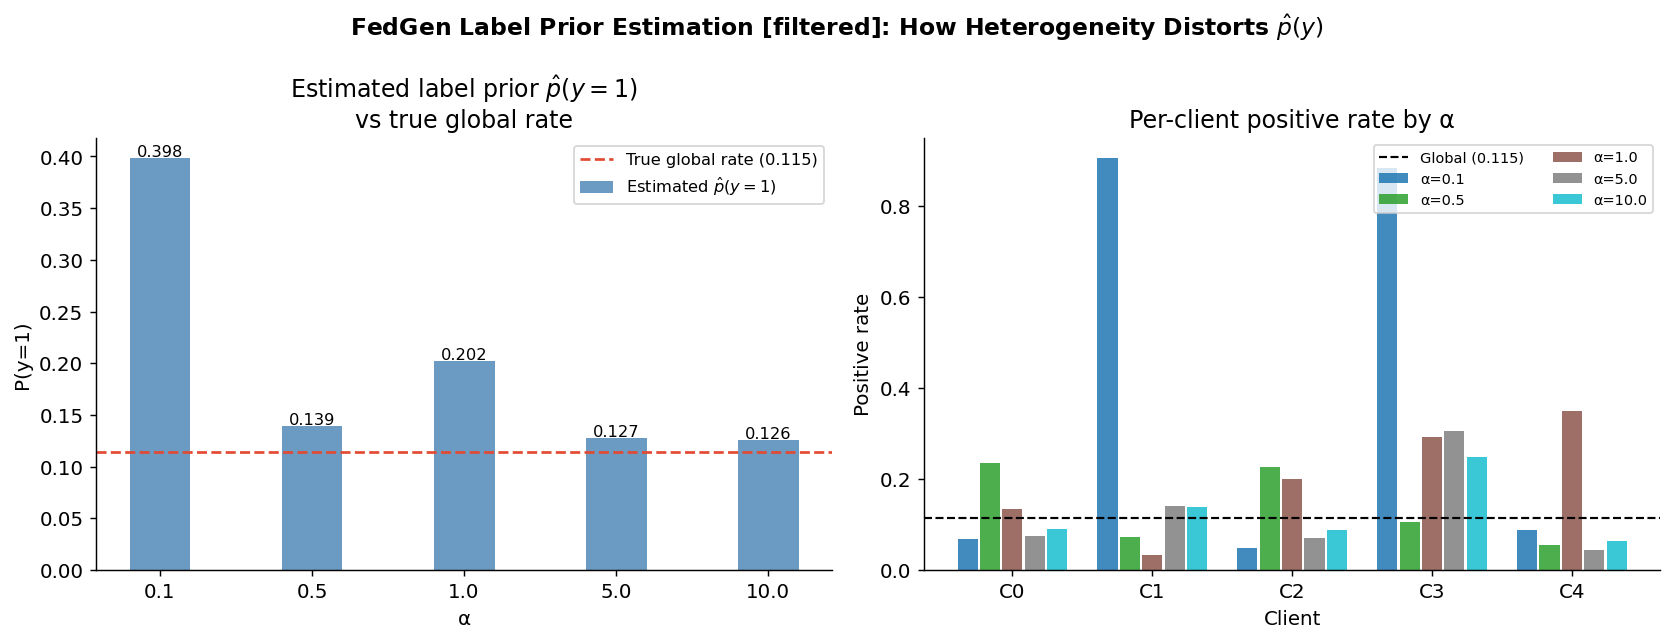

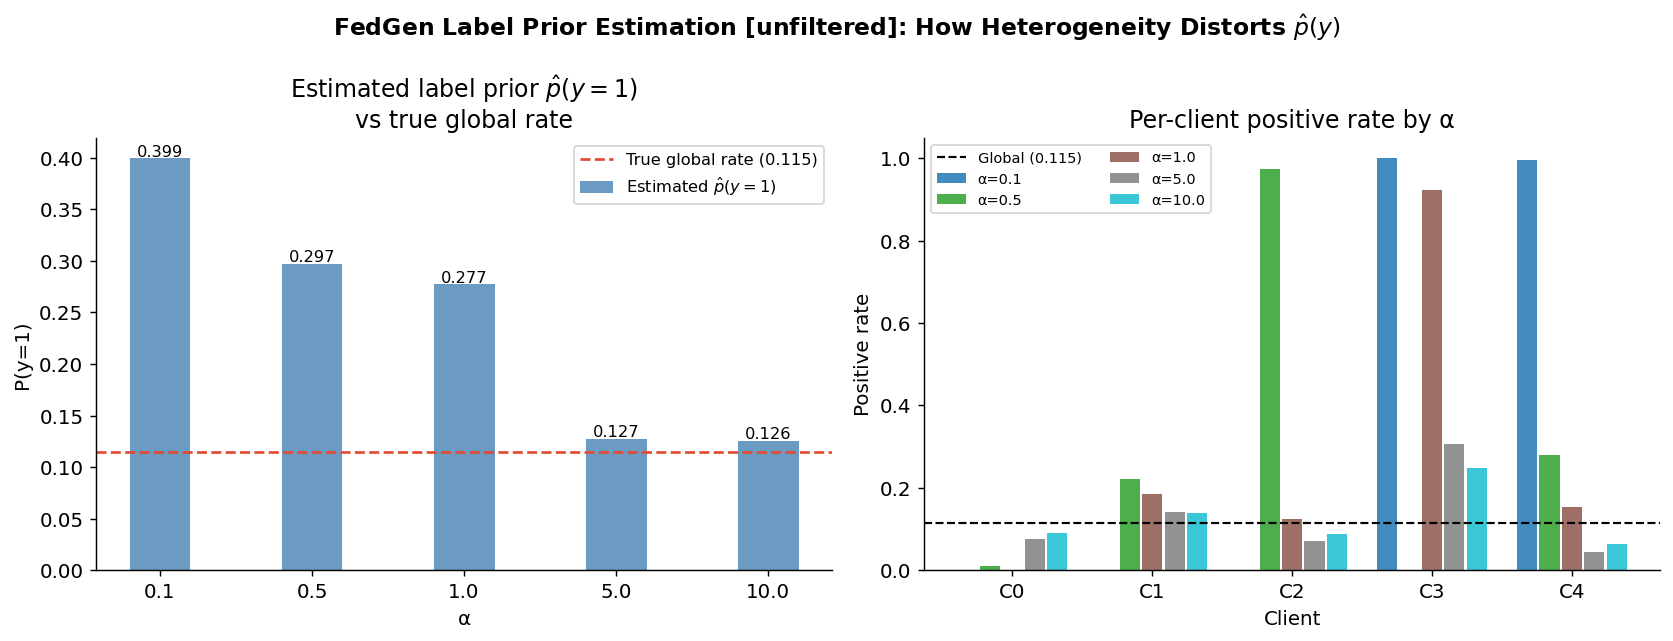

In [10]:
for eff_df, label in [(eff_df_filtered, 'filtered'), (eff_df_unfiltered, 'unfiltered')]:
    plot_label_prior(eff_df, y, N_CLIENTS, ALPHA_SWEEP, label=label)

# Heterogeny metrics

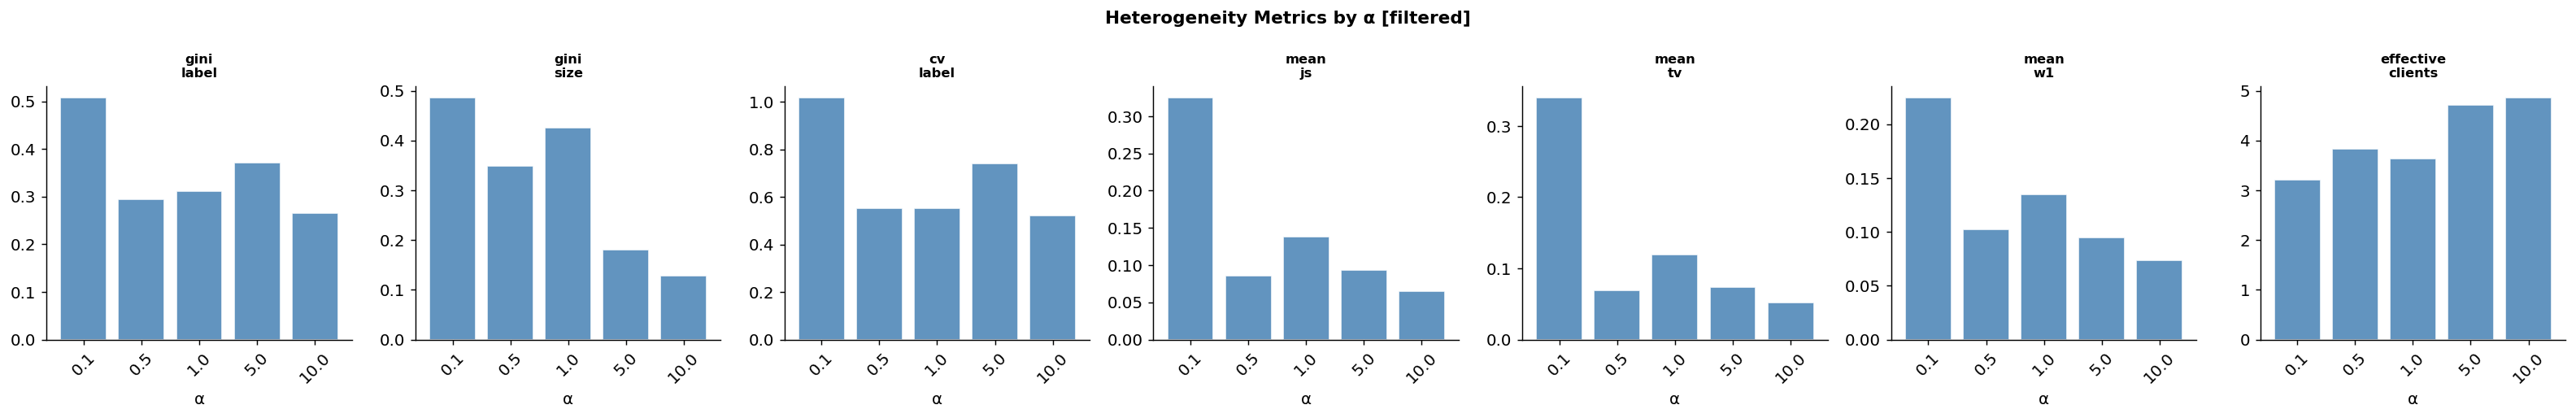


Heterogeneity summary [filtered]:
 alpha  gini_size  gini_label  cv_label  mean_js   max_js  mean_tv  mean_w1  effective_clients
   0.1   0.485534    0.507357  1.016306 0.324615 0.716930 0.339435 0.224487           3.215653
   0.5   0.348679    0.294838  0.551740 0.085701 0.136201 0.068709 0.102092           3.825003
   1.0   0.426214    0.311278  0.552523 0.138057 0.240176 0.119712 0.134639           3.634751
   5.0   0.180184    0.371504  0.742331 0.093460 0.202453 0.073925 0.094980           4.718259
  10.0   0.128980    0.264817  0.521271 0.065011 0.147882 0.051529 0.073516           4.855549


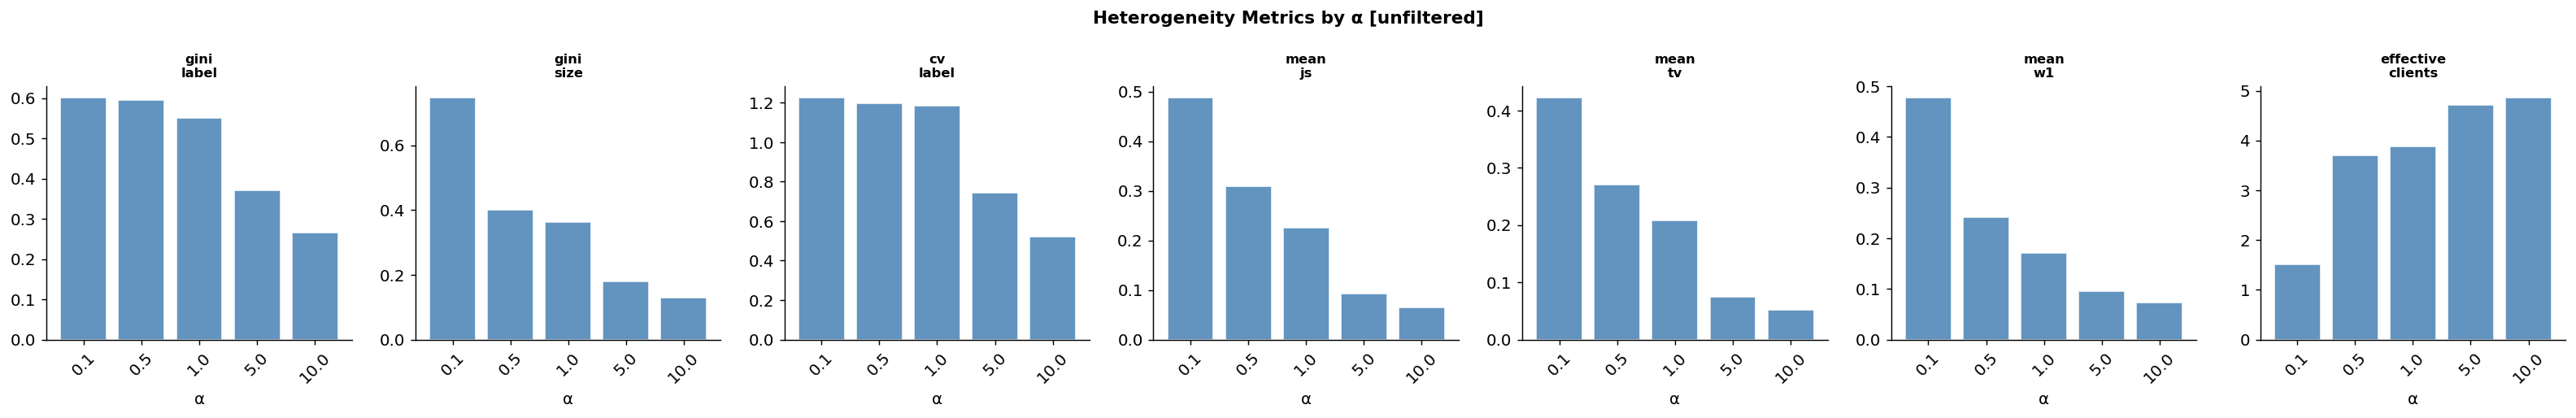


Heterogeneity summary [unfiltered]:
 alpha  gini_size  gini_label  cv_label  mean_js   max_js  mean_tv  mean_w1  effective_clients
   0.1   0.746296    0.600265  1.224747 0.487546 0.855653 0.422285 0.476755           1.508198
   0.5   0.401387    0.595928  1.196572 0.308795 0.805146 0.270131 0.240957           3.706052
   1.0   0.363836    0.549867  1.185964 0.225514 0.739823 0.208588 0.170345           3.873938
   5.0   0.180184    0.371504  0.742331 0.093460 0.202453 0.073925 0.094980           4.718259
  10.0   0.128980    0.264817  0.521271 0.065011 0.147882 0.051529 0.073516           4.855549


In [11]:
het_df_filtered   = compute_heterogeneity_metrics(
    filtered_partitions,   patient_labels_map, y, wass_df_filtered)
het_df_unfiltered = compute_heterogeneity_metrics(
    unfiltered_partitions, patient_labels_map, y, wass_df_unfiltered)

for het_df, label in [(het_df_filtered, 'filtered'), (het_df_unfiltered, 'unfiltered')]:
    plot_heterogeneity_summary(het_df, label)

# Gini analysis

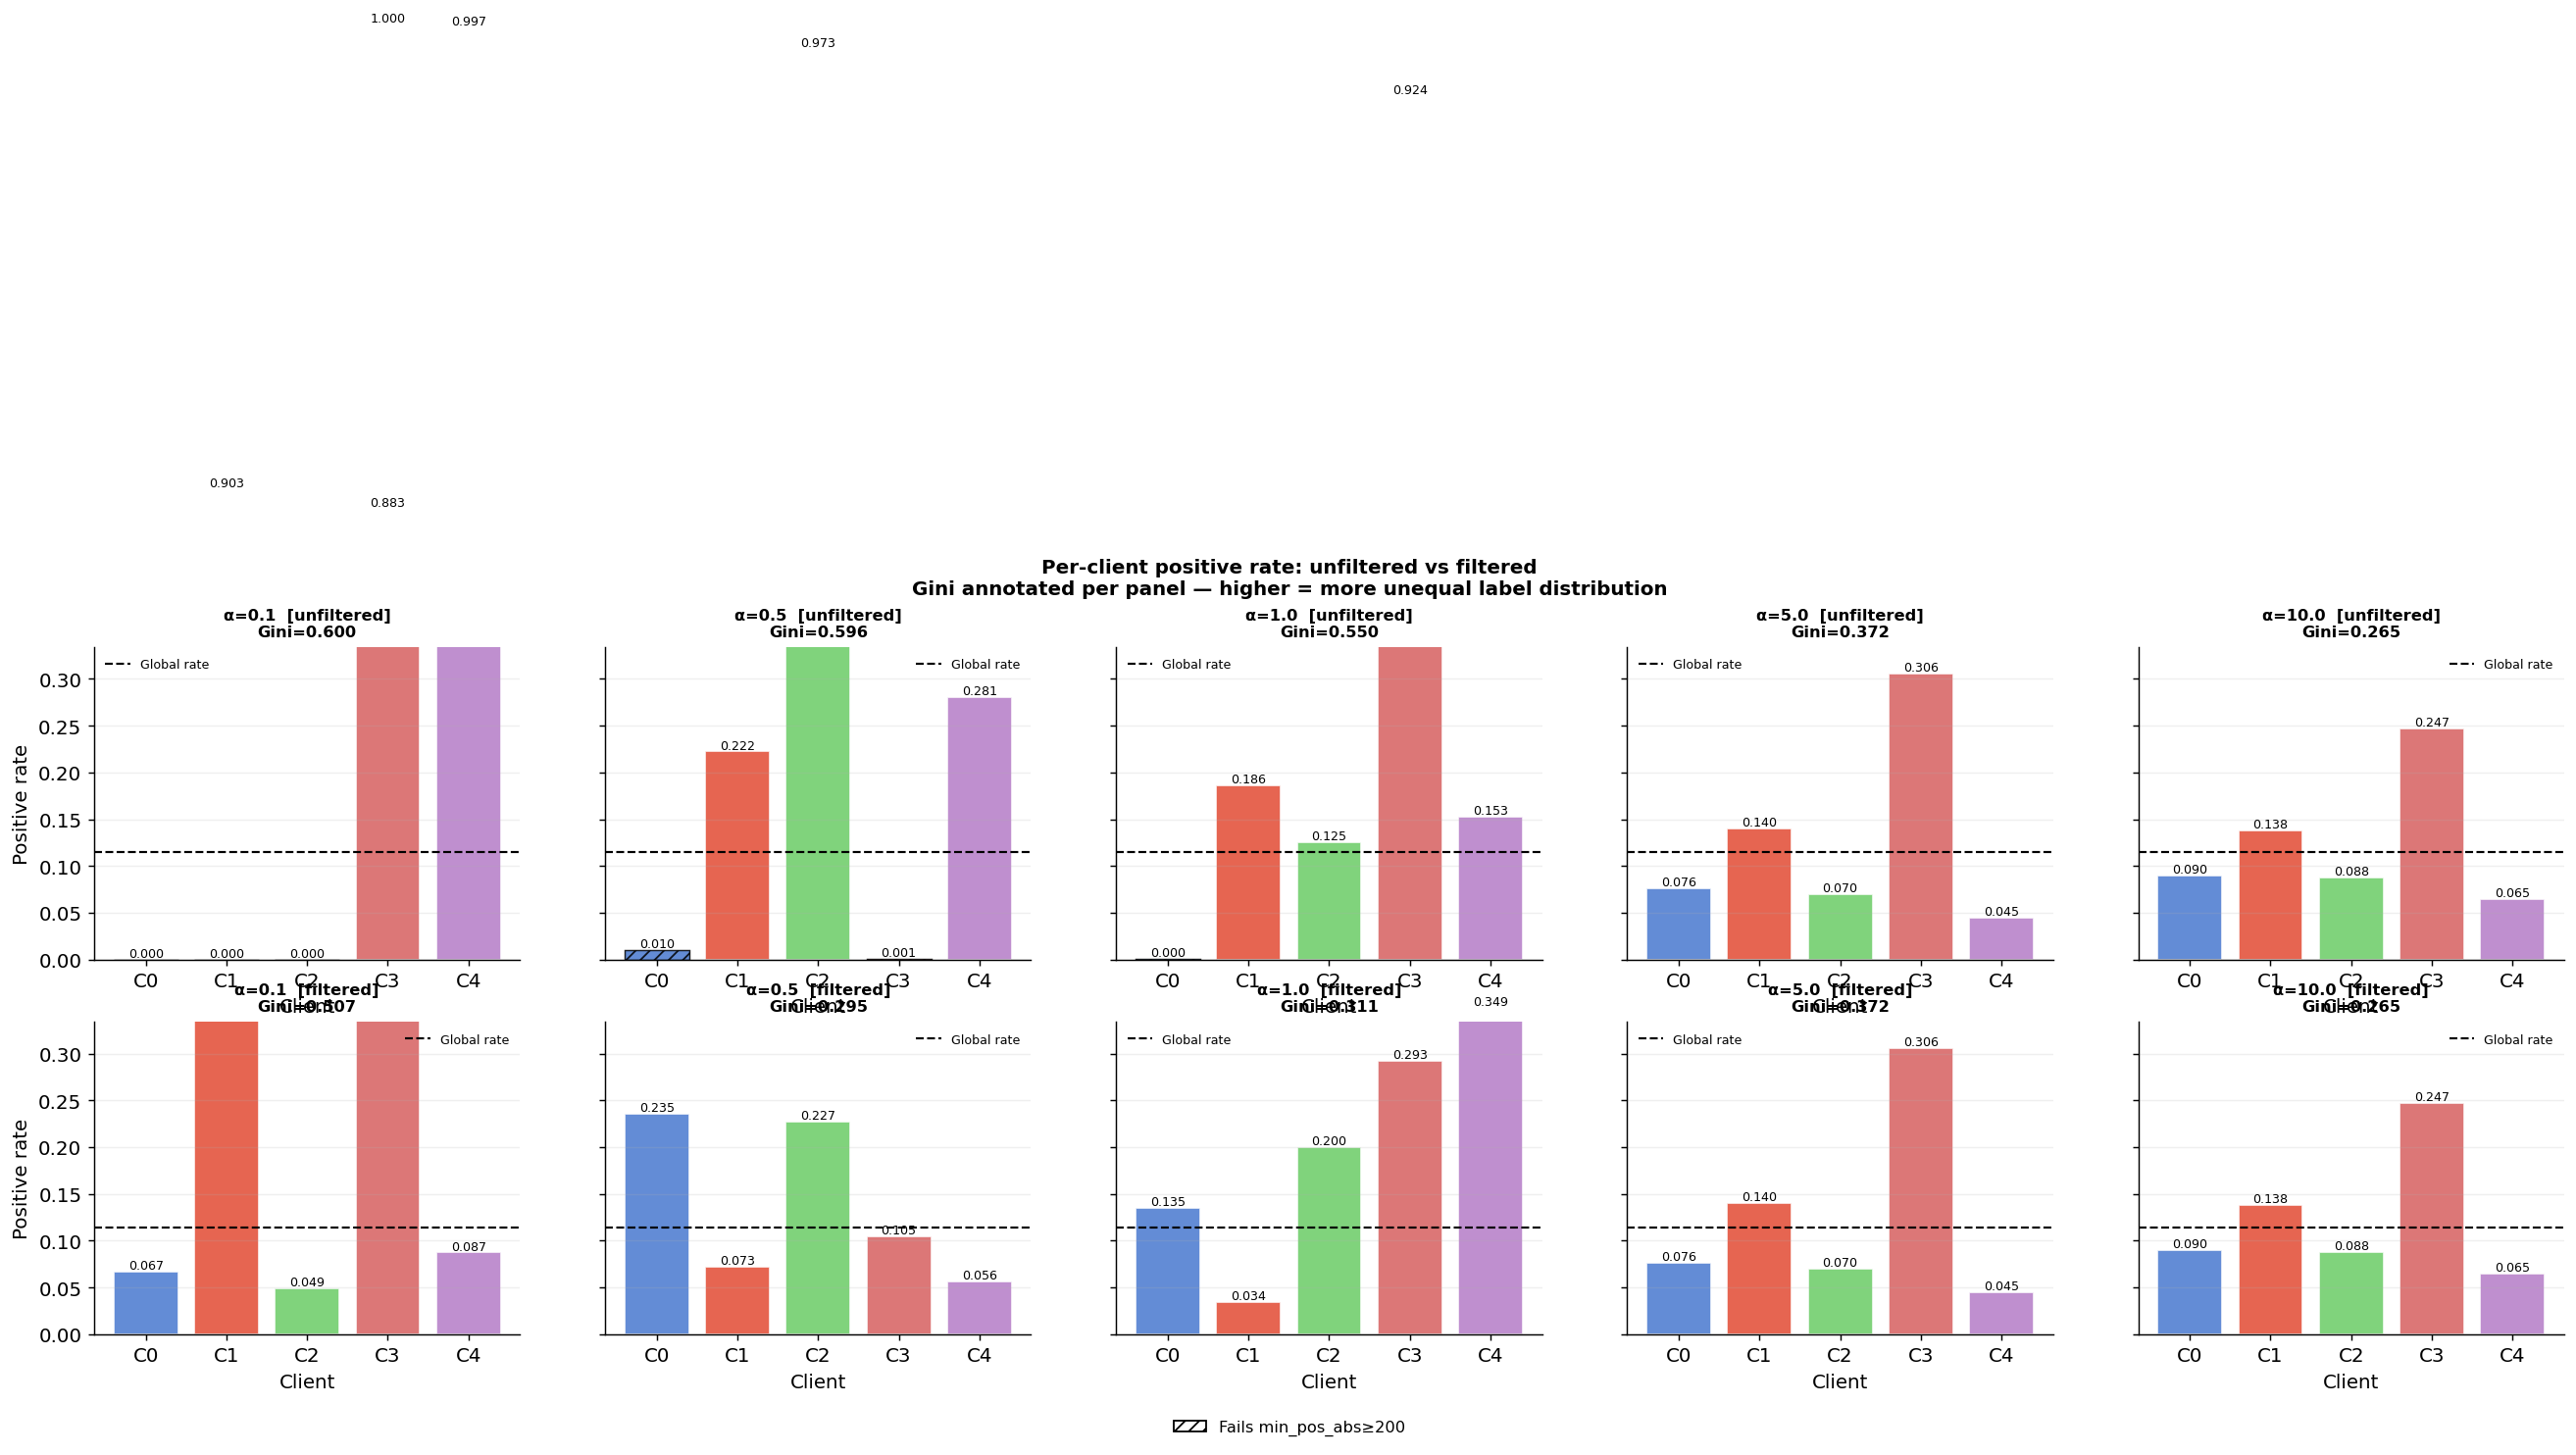

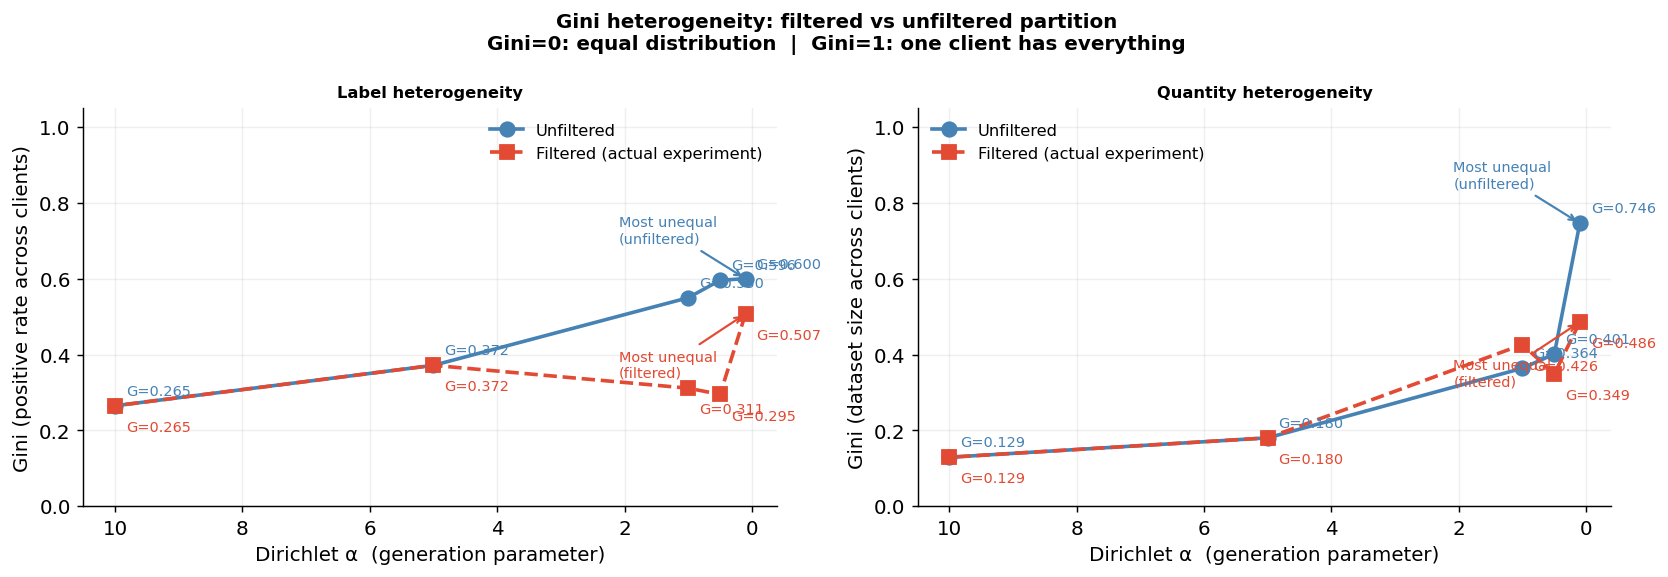


α      Source                   Gini label  Gini size
------------------------------------------------------
0.1    unfiltered                   0.6003     0.7463
0.1    filtered                     0.5074     0.4855

0.5    unfiltered                   0.5959     0.4014
0.5    filtered                     0.2948     0.3487

1.0    unfiltered                   0.5499     0.3638
1.0    filtered                     0.3113     0.4262

5.0    unfiltered                   0.3715     0.1802
5.0    filtered                     0.3715     0.1802

10.0   unfiltered                   0.2648     0.1290
10.0   filtered                     0.2648     0.1290



In [12]:
# ── Gini analysis: filtered vs unfiltered ─────────────────────────────────────
global_pos_rate = y.mean()

filtered_gini_df, filtered_gini_summary     = compute_gini_df(
    filtered_partitions,   patient_labels_map, 'filtered')
unfiltered_gini_df, unfiltered_gini_summary = compute_gini_df(
    unfiltered_partitions, patient_labels_map, 'unfiltered')

plot_gini_per_client_bars(
    filtered_gini_df, unfiltered_gini_df,
    ALPHA_SWEEP, global_pos_rate, N_CLIENTS
)

plot_gini_lines(
    filtered_gini_summary, unfiltered_gini_summary, ALPHA_SWEEP
)